In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [4]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

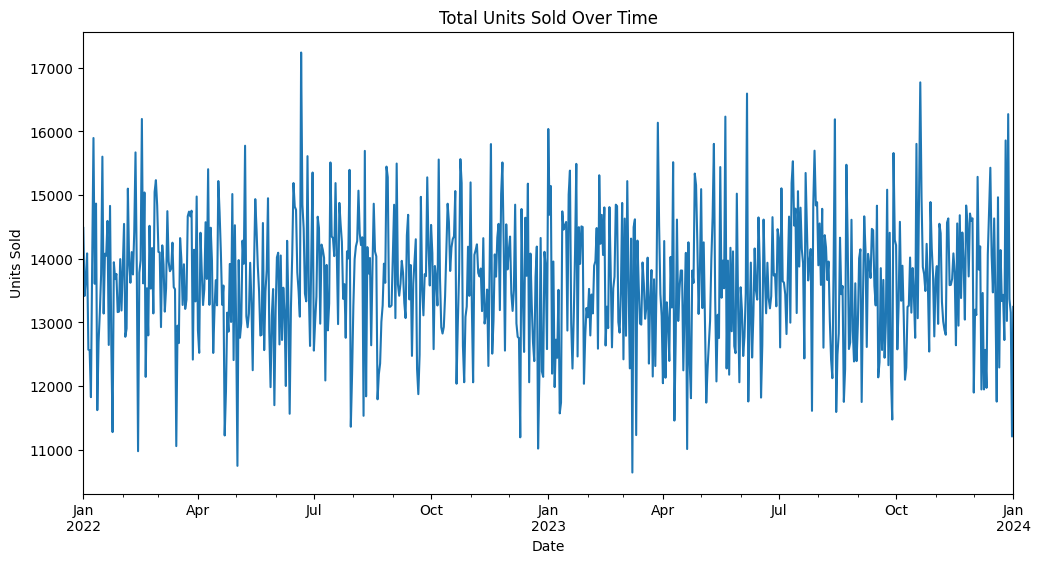

In [6]:
sales_over_time = df.groupby('Date')['Units Sold'].sum()

sales_over_time.plot(figsize=(12,6))
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

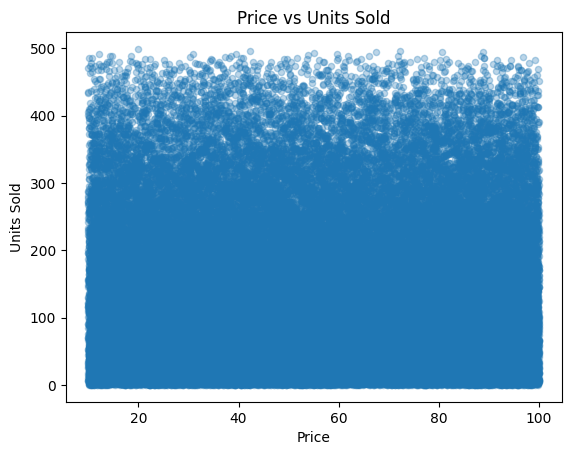

In [7]:
df.plot.scatter(x='Price', y='Units Sold', alpha=0.3)
plt.title("Price vs Units Sold")
plt.show()

In [8]:
sample_product = df['Product ID'].iloc[0]

df_product = df[df['Product ID'] == sample_product]

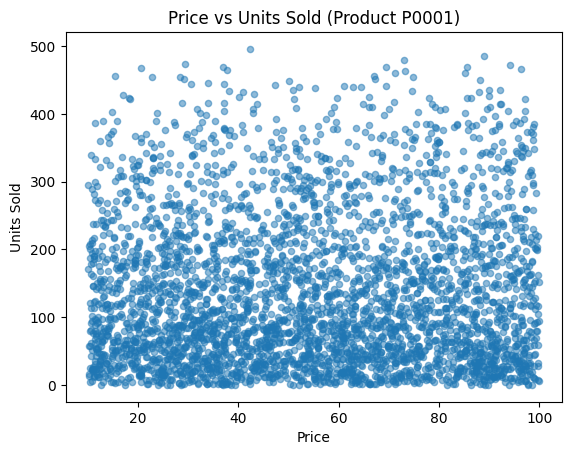

In [9]:
df_product.plot.scatter(x='Price', y='Units Sold', alpha=0.5)
plt.title(f"Price vs Units Sold (Product {sample_product})")
plt.show()

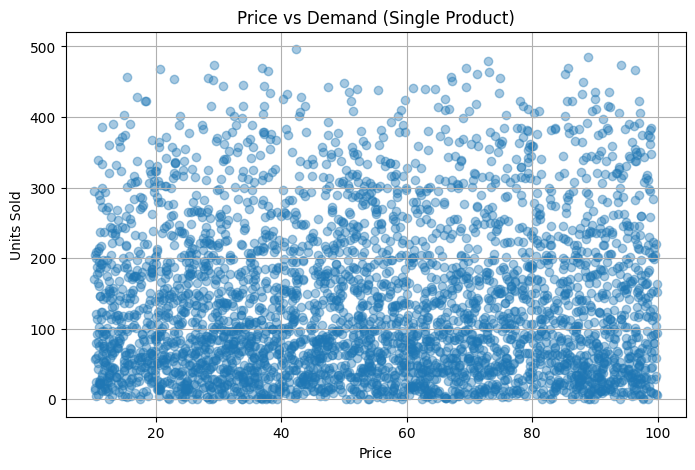

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df_product['Price'], df_product['Units Sold'], alpha=0.4)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Demand (Single Product)")
plt.grid(True)
plt.show()

In [11]:
df_clean = df_product[df_product['Holiday/Promotion'] == 0]

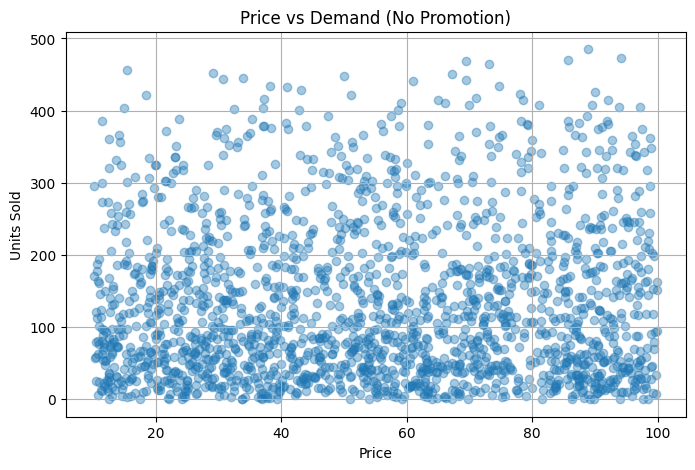

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Price'], df_clean['Units Sold'], alpha=0.4)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Demand (No Promotion)")
plt.grid(True)
plt.show()

/tmp/ipykernel_5896/3838926518.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_product['price_bin'] = pd.cut(df_product['Price'], bins=10)
/tmp/ipykernel_5896/3838926518.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_demand = df_product.groupby('price_bin')['Units Sold'].mean()


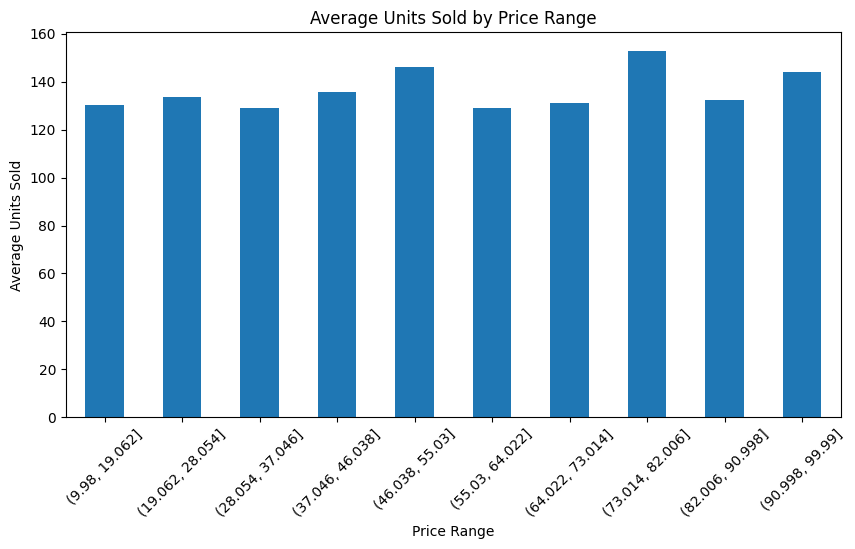

In [13]:
# Create price bins
df_product['price_bin'] = pd.cut(df_product['Price'], bins=10)

# Average demand per bin
price_demand = df_product.groupby('price_bin')['Units Sold'].mean()

# Plot
price_demand.plot(kind='bar', figsize=(10,5))
plt.title("Average Units Sold by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

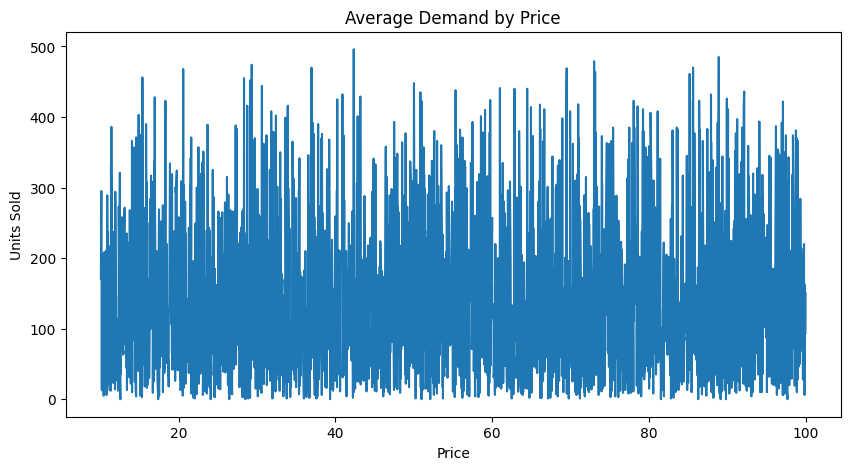

In [14]:
df_sorted = df_product.sort_values('Price')

df_sorted.groupby('Price')['Units Sold'].mean().plot(figsize=(10,5))

plt.title("Average Demand by Price")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()

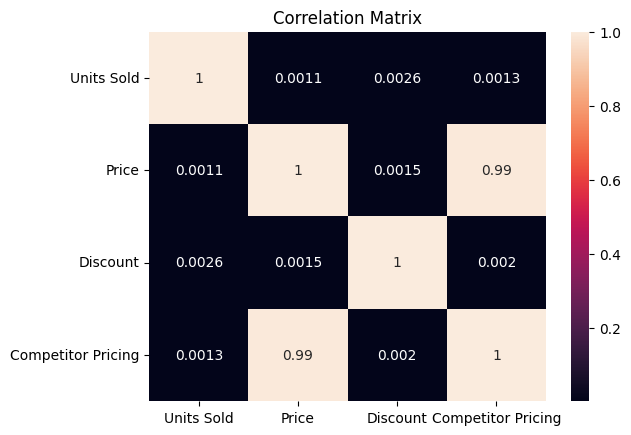

In [15]:
import seaborn as sns

corr = df[['Units Sold', 'Price', 'Discount', 'Competitor Pricing']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

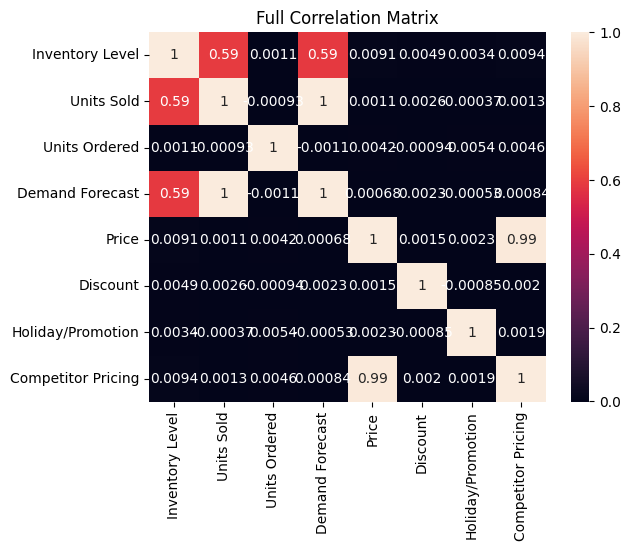

In [16]:
corr_full = df.corr(numeric_only=True)

sns.heatmap(corr_full, annot=True)
plt.title("Full Correlation Matrix")
plt.show()

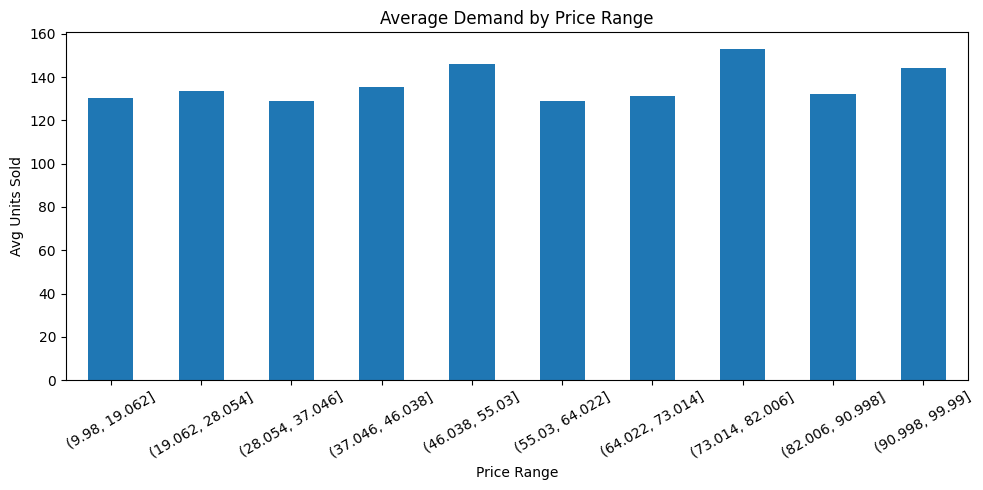

In [17]:
price_demand.plot(kind='bar', figsize=(10,5))
plt.title("Average Demand by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Avg Units Sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

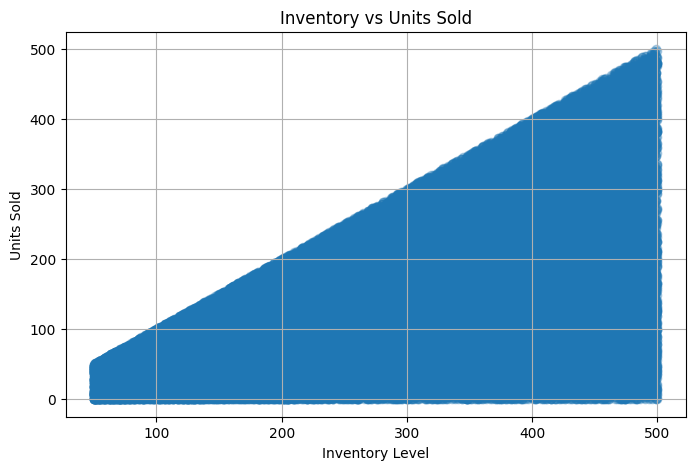

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Inventory Level'], df['Units Sold'], alpha=0.3)
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.title("Inventory vs Units Sold")
plt.grid(True)
plt.show()

/tmp/ipykernel_5896/1869572913.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inventory_demand = df.groupby(inventory_bins)['Units Sold'].mean()


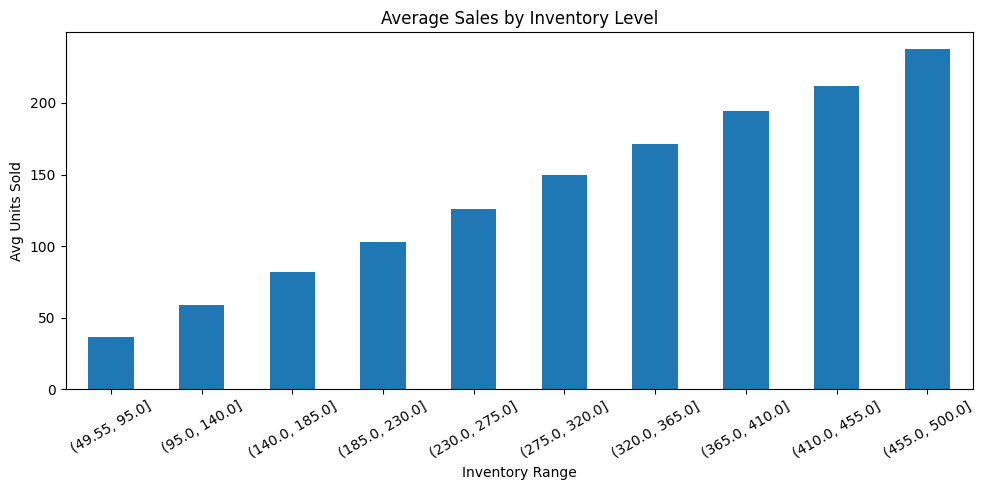

In [19]:
inventory_bins = pd.cut(df['Inventory Level'], bins=10)
inventory_demand = df.groupby(inventory_bins)['Units Sold'].mean()

inventory_demand.plot(kind='bar', figsize=(10,5))
plt.title("Average Sales by Inventory Level")
plt.xlabel("Inventory Range")
plt.ylabel("Avg Units Sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [21]:
df = df.dropna()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [26]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [27]:
df = df[df['Demand Forecast'] >= 0]

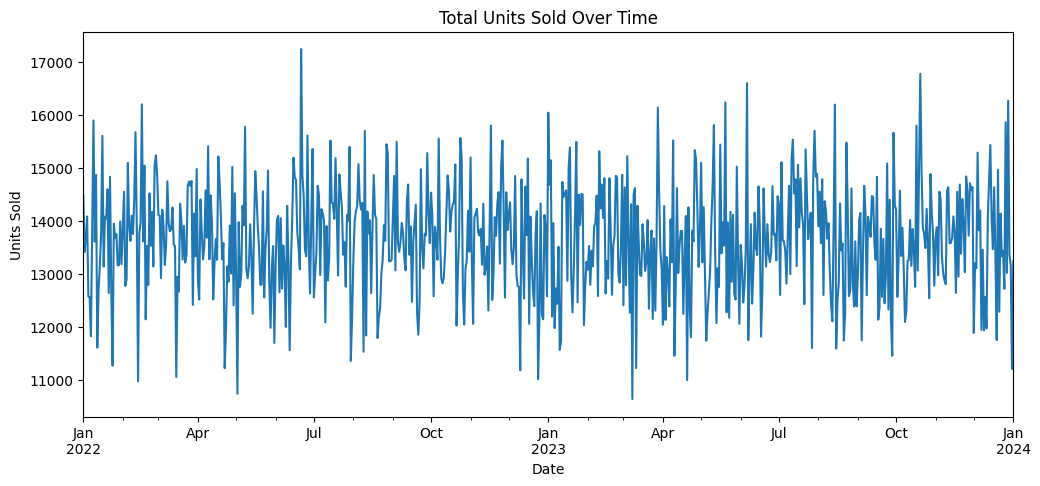

In [28]:
daily_sales = df.groupby('Date')['Units Sold'].sum()

daily_sales.plot(figsize=(12,5), title='Total Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

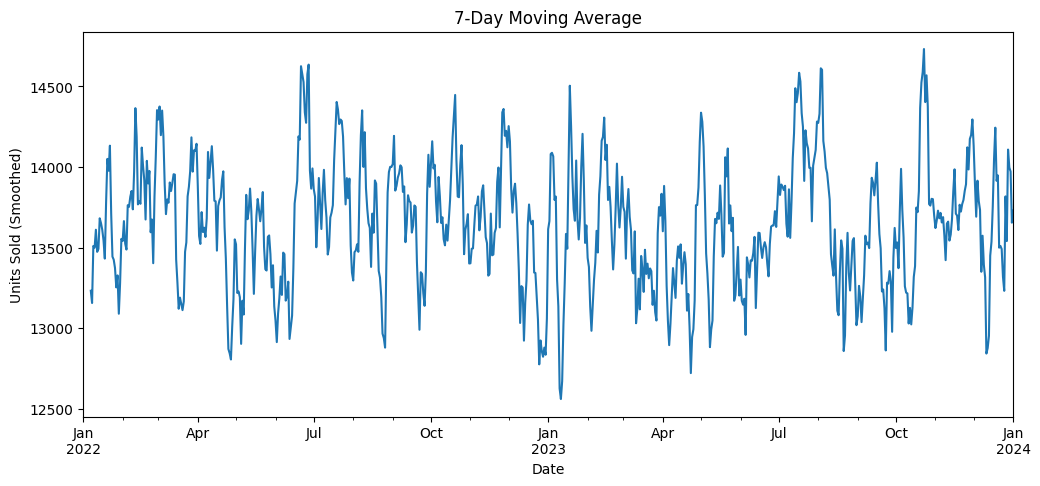

In [29]:
daily_sales.rolling(window=7).mean().plot(figsize=(12,5), title='7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Units Sold (Smoothed)')
plt.show()

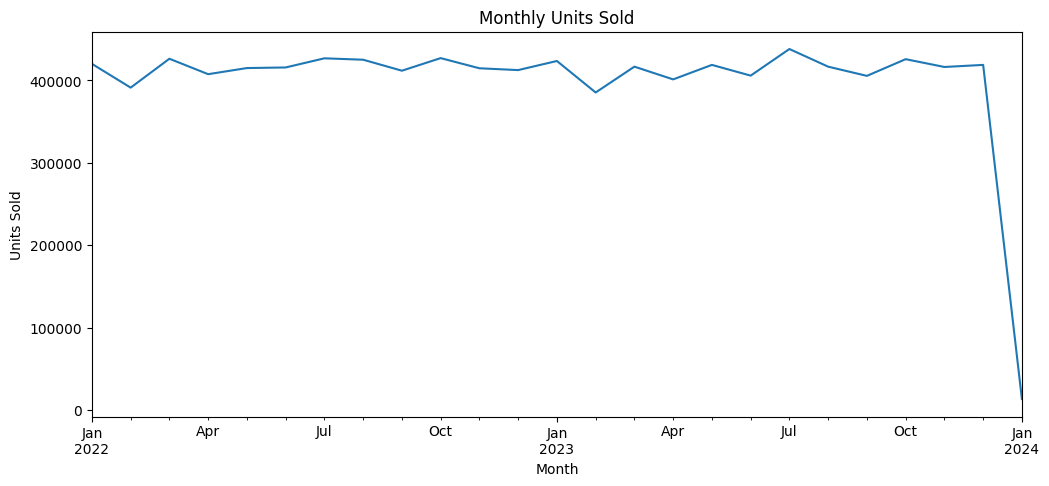

In [30]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Units Sold'].sum()

monthly_sales.plot(figsize=(12,5), title='Monthly Units Sold')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.show()

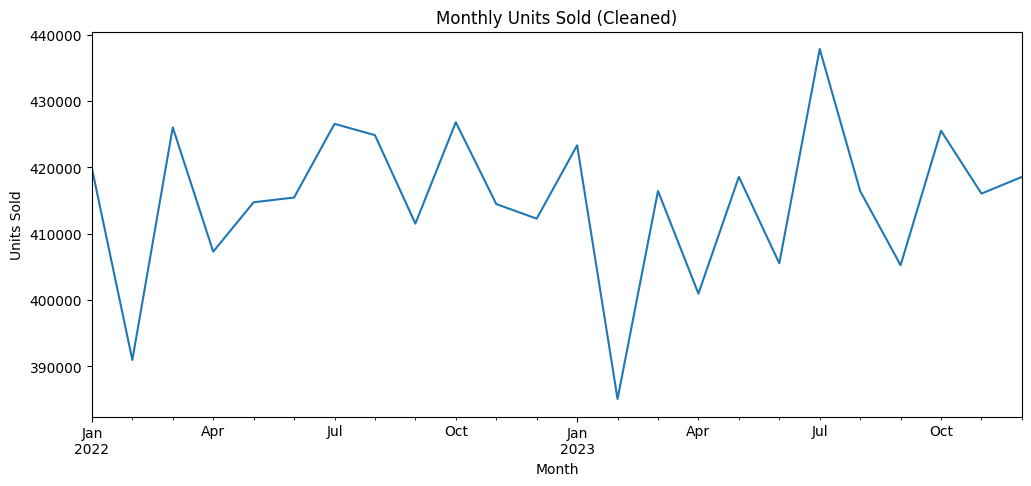

In [31]:
monthly_sales = df.groupby('Month')['Units Sold'].sum()

monthly_sales = monthly_sales[:-1]  # remove last month

monthly_sales.plot(figsize=(12,5), title='Monthly Units Sold (Cleaned)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.show()

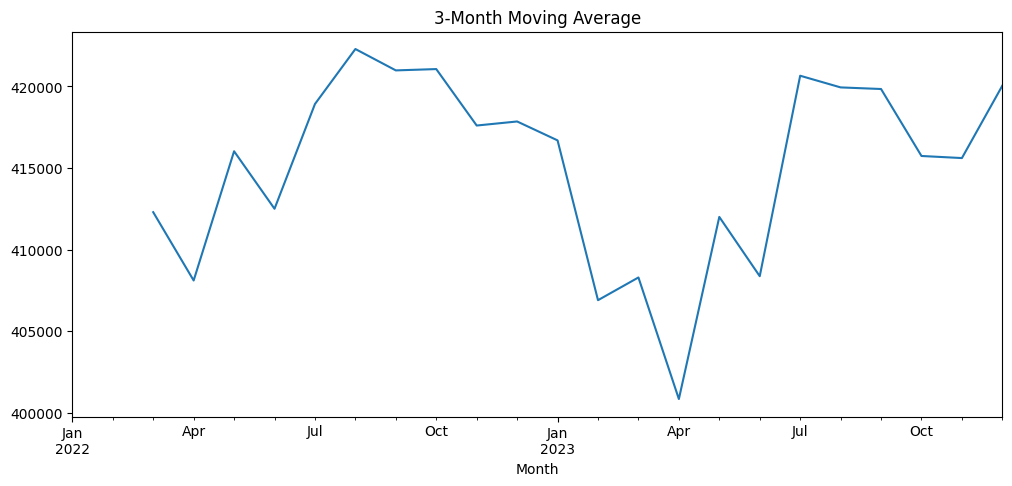

In [32]:
monthly_sales.rolling(3).mean().plot(figsize=(12,5), title='3-Month Moving Average')
plt.show()

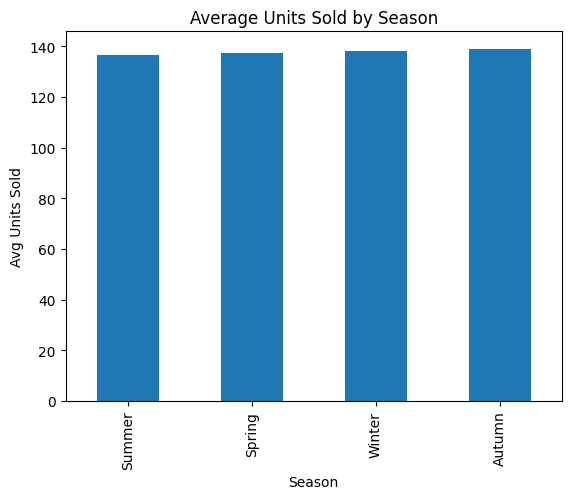

In [33]:
df.groupby('Seasonality')['Units Sold'].mean().sort_values().plot(kind='bar')
plt.title('Average Units Sold by Season')
plt.xlabel('Season')
plt.ylabel('Avg Units Sold')
plt.show()

In [34]:
df['Seasonality'].value_counts()

,count
Seasonality,
Summer,18133
Winter,18129
Spring,18125
Autumn,18040


In [35]:
df.groupby('Seasonality')['Units Sold'].mean().sort_values()

,Units Sold
Seasonality,
Summer,136.684443
Spring,137.232552
Winter,137.985162
Autumn,138.927384


In [36]:
df.groupby('Holiday/Promotion')['Units Sold'].mean()

,Units Sold
Holiday/Promotion,
0,137.788120
1,137.622748


In [37]:
df.groupby('Category')['Units Sold'].mean().sort_values()

,Units Sold
Category,
Electronics,136.190175
Toys,137.218162
Clothing,137.906582
Groceries,138.241360
Furniture,138.957035
